In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from concrete.ml.sklearn import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error 
from sklearn.metrics import explained_variance_score
from matplotlib import pyplot as plt

# Small Random Dataset - 100 samples

Make regression samples and perform train and test split

In [2]:
sd_x, sd_y = make_regression(n_samples=100, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", sd_x.min())
print("X Maximum: ", sd_x.max())

sd_x_train, sd_x_test, sd_y_train, sd_y_test = train_test_split(sd_x, sd_y, test_size=0.1, random_state=42)

X Minimum:  -2.6197451040897444
X Maximum:  1.8522781845089378


Evaluate number of training and testing samples from train/test split

In [3]:
num_sd_x_training = len(sd_x_train)
num_sd_x_test = len(sd_x_test)
num_sd_y_training = len(sd_y_train)
num_sd_y_test = len(sd_y_test)

print("Number of x training: ", num_sd_x_training)
print("Number of x test: ", num_sd_x_test)
print("Number of y training: ", num_sd_y_training)
print("Number of y test: ", num_sd_y_test)

Number of x training:  90
Number of x test:  10
Number of y training:  90
Number of y test:  10


In [4]:
print("sd_x_train shape: ", sd_x_train.shape)
print("sd_x_test shape: ", sd_x_test.shape)
print("sd_y_train shape: ", sd_y_train.shape)
print("sd_y_test shape: ", sd_y_train.shape) 

sd_x_train shape:  (90, 1)
sd_x_test shape:  (10, 1)
sd_y_train shape:  (90,)
sd_y_test shape:  (90,)


Initialise Model and Perform Fitting and Prediction

In [5]:
sd_total_start_time = time.time()

sd_model = LinearRegression(n_bits=8)

sd_ml_start_time = time.time()

sd_model.fit(sd_x_train, sd_y_train)
sd_y_pred_clear = sd_model.predict(sd_x_test)
sd_model.compile(sd_x_train)

sd_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmp9ljhmc7w/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [6]:
sd_clear_mse = mean_squared_error(sd_y_test, sd_y_pred_clear)
sd_clear_mae = mean_absolute_error(sd_y_test, sd_y_pred_clear)
sd_clear_mape = mean_absolute_percentage_error(sd_y_test, sd_y_pred_clear)
sd_clear_r2 = r2_score(sd_y_test, sd_y_pred_clear)
sd_clear_explained_var = explained_variance_score(sd_y_test, sd_y_pred_clear)
sd_ml_elapsed_time = sd_ml_end_time - sd_ml_start_time

print("Mean Squared Error (MSE):", sd_clear_mse)
print("Mean Absolute Error (MAE):", sd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", sd_clear_mape)
print("R-squared Score (R²):", sd_clear_r2)
print("Explained Variance Score:", sd_clear_explained_var)
print(f"Time it took for ML to make predictions: {sd_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1170.1469904739056
Mean Absolute Error (MAE): 29.23528899387278
Mean Absolute Percentage Error (MAPE): 1.026348459498222
R-squared Score (R²): 0.6684359976906726
Explained Variance Score: 0.8221459912801368
Time it took for ML to make predictions: 0.16644 seconds


Prediction v Actual Plot - Cleartext

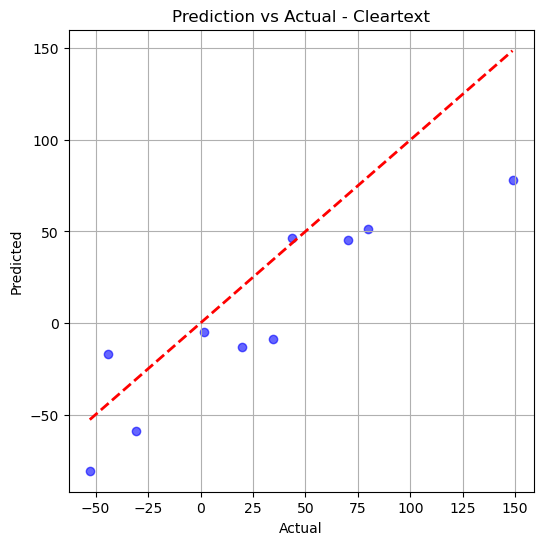

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(sd_y_test, sd_y_pred_clear, color='blue', alpha=0.6)
plt.plot([sd_y_test.min(), sd_y_test.max()],
         [sd_y_test.min(), sd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Cleartext

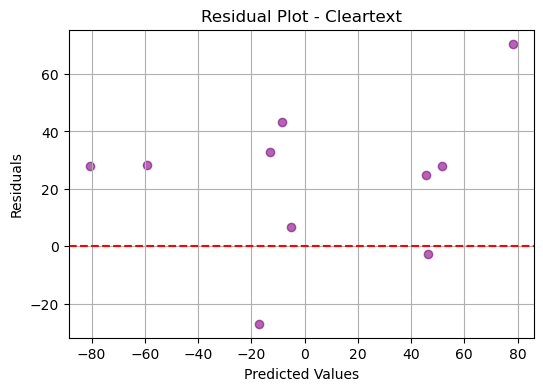

In [8]:
residuals = sd_y_test - sd_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(sd_y_pred_clear, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Cleartext

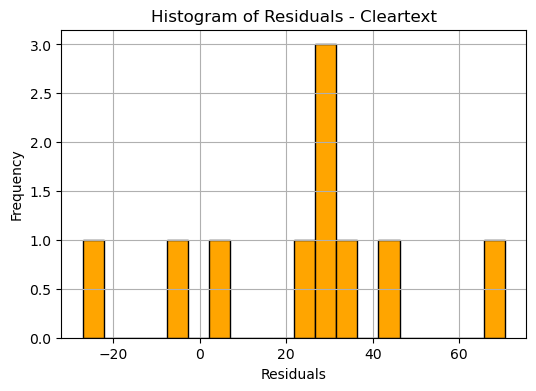

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

FHE Execution and Evaluation

In [10]:
sd_fhe_prediction_start_time = time.time()

sd_y_pred_fhe = sd_model.predict(sd_x_test, fhe="execute")

sd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [11]:
sd_fhe_mse = mean_squared_error(sd_y_test, sd_y_pred_fhe)
sd_fhe_mae = mean_absolute_error(sd_y_test, sd_y_pred_fhe)
sd_fhe_mape = mean_absolute_percentage_error(sd_y_test, sd_y_pred_fhe)
sd_fhe_r2 = r2_score(sd_y_test, sd_y_pred_fhe)
sd_fhe_explained_var = explained_variance_score(sd_y_test, sd_y_pred_fhe)
sd_fhe_elapsed_time = sd_fhe_prediction_end_time - sd_fhe_prediction_start_time

print("Mean Squared Error (MSE):", sd_clear_mse)
print("Mean Absolute Error (MAE):", sd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", sd_clear_mape)
print("R-squared Score (R²):", sd_clear_r2)
print("Explained Variance Score:", sd_clear_explained_var)
print(f"Time it took for FHE to make predictions: {sd_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1170.1469904739056
Mean Absolute Error (MAE): 29.23528899387278
Mean Absolute Percentage Error (MAPE): 1.026348459498222
R-squared Score (R²): 0.6684359976906726
Explained Variance Score: 0.8221459912801368
Time it took for FHE to make predictions: 0.50339 seconds


Prediction v Actual Plot - FHE

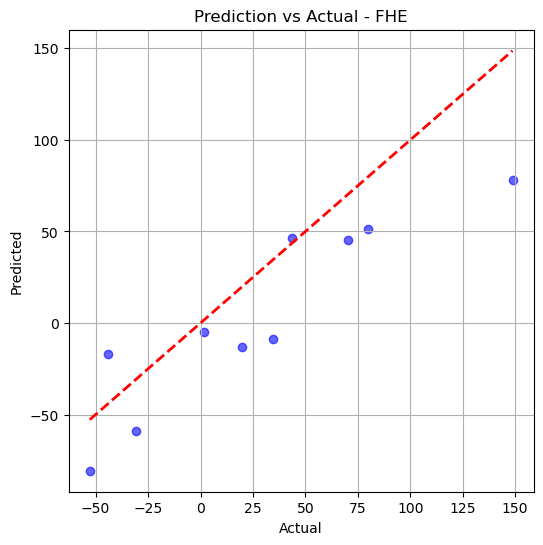

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(sd_y_test, sd_y_pred_fhe, color='blue', alpha=0.6)
plt.plot([sd_y_test.min(), sd_y_test.max()],
         [sd_y_test.min(), sd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

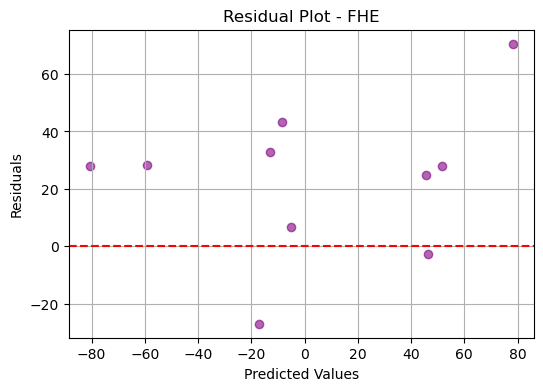

In [13]:
residuals = sd_y_test - sd_y_pred_fhe

plt.figure(figsize=(6, 4))
plt.scatter(sd_y_pred_fhe, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

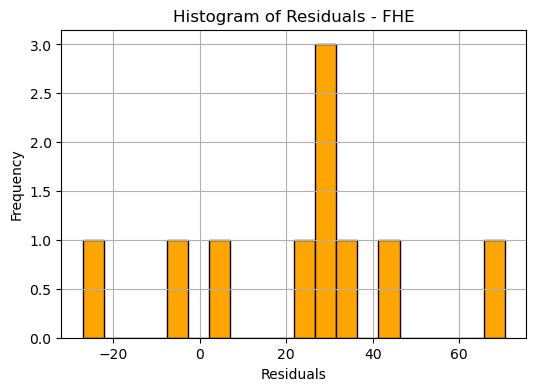

In [14]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of SD Model

In [15]:
print("In clear  :", sd_y_pred_clear)
print("In FHE    :", sd_y_pred_fhe)
print(f"Similarity: {int((sd_y_pred_fhe == sd_y_pred_clear).mean()*100)}%")

sd_total_end_time = time.time()
sd_total_elapsed_time = sd_total_end_time - sd_total_start_time
print(f"Total time for SD to Run: {sd_total_elapsed_time:.5f} seconds")

In clear  : [-59.23225407  78.1179003   45.49723863 -12.87657697  -5.15063079
  -8.58438465 -17.1687693  -80.69321569  46.3556771   51.50630789]
In FHE    : [-59.23225407  78.1179003   45.49723863 -12.87657697  -5.15063079
  -8.58438465 -17.1687693  -80.69321569  46.3556771   51.50630789]
Similarity: 100%
Total time for SD to Run: 1.25693 seconds


# Medium Random Dataset - 1000 samples

Make regression samples and perform train and test split

In [16]:
md_x, md_y = make_regression(n_samples=1000, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", md_x.min())
print("X Maximum: ", md_x.max())

md_x_train, md_x_test, md_y_train, md_y_test = train_test_split(md_x, md_y, test_size=0.1, random_state=42)

X Minimum:  -3.2412673400690726
X Maximum:  3.8527314906547208


Evaluate number of training and testing samples from train/test split

In [17]:
num_md_x_training = len(md_x_train)
num_md_x_test = len(md_x_test)
num_md_y_training = len(md_y_train)
num_md_y_test = len(md_y_test)

print("Number of x training: ", num_md_x_training)
print("Number of x test: ", num_md_x_test)
print("Number of y training: ", num_md_y_training)
print("Number of y test: ", num_md_y_test)

Number of x training:  900
Number of x test:  100
Number of y training:  900
Number of y test:  100


In [18]:
print("md_x_train shape: ", md_x_train.shape)
print("md_x_test shape: ", md_x_test.shape)
print("md_y_train shape: ", md_y_train.shape)
print("md_y_test shape: ", md_y_train.shape) 

md_x_train shape:  (900, 1)
md_x_test shape:  (100, 1)
md_y_train shape:  (900,)
md_y_test shape:  (900,)


Initialise Model and Perform Fitting and Prediction

In [19]:
md_total_start_time = time.time()

md_model = LinearRegression(n_bits=8)
md_ml_start_time = time.time()

md_model.fit(md_x_train, md_y_train)
md_y_pred_clear = md_model.predict(md_x_test)
md_model.compile(md_x_train)

md_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmpc7qdng6d/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [20]:
md_clear_mse = mean_squared_error(md_y_test, md_y_pred_clear)
md_clear_mae = mean_absolute_error(md_y_test, md_y_pred_clear)
md_clear_mape = mean_absolute_percentage_error(md_y_test, md_y_pred_clear)
md_clear_r2 = r2_score(md_y_test, md_y_pred_clear)
md_clear_explained_var = explained_variance_score(md_y_test, md_y_pred_clear)
md_ml_elapsed_time = md_ml_end_time - md_ml_start_time

print("Mean Squared Error (MSE):", md_clear_mse)
print("Mean Absolute Error (MAE):", md_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", md_clear_mape)
print("R-squared Score (R²):", md_clear_r2)
print("Explained Variance Score:", md_clear_explained_var)
print(f"Time it took for ML to make predictions: {md_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1031.817173414091
Mean Absolute Error (MAE): 25.582954707350336
Mean Absolute Percentage Error (MAPE): 1.3381445489323858
R-squared Score (R²): 0.18847004402654666
Explained Variance Score: 0.19141975145091283
Time it took for ML to make predictions: 0.23691 seconds


Prediction v Actual Plot - Cleartext

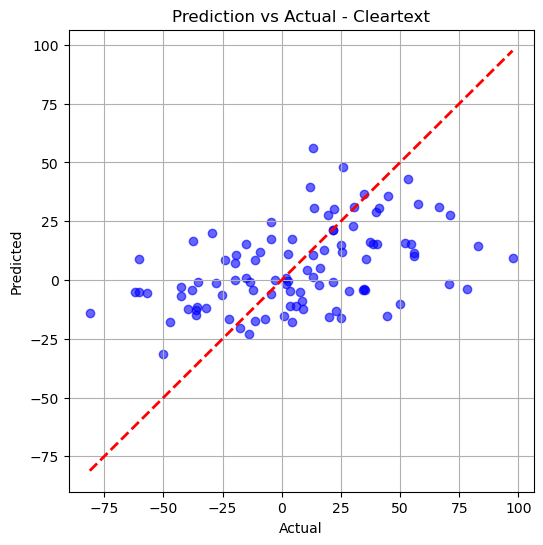

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(md_y_test, md_y_pred_clear, color='blue', alpha=0.6)
plt.plot([md_y_test.min(), md_y_test.max()],
         [md_y_test.min(), md_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Cleartext

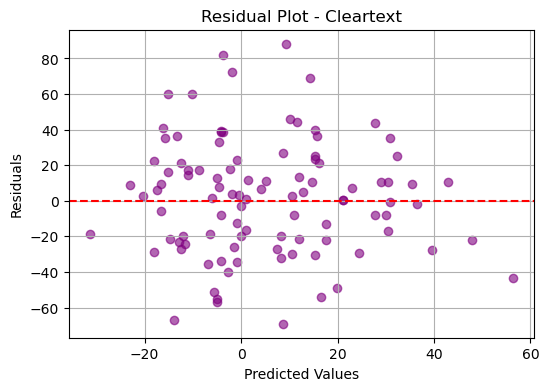

In [22]:
residuals = md_y_test - md_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(md_y_pred_clear, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Cleartext

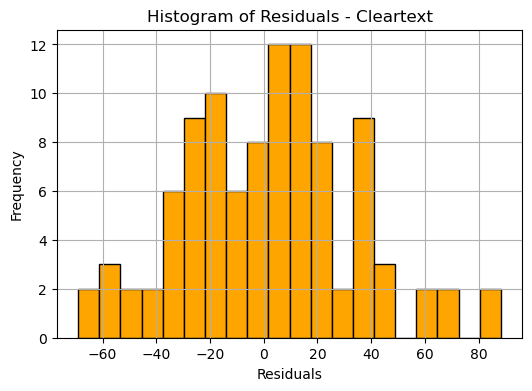

In [23]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

FHE Execution and Evaluation

In [24]:
md_fhe_prediction_start_time = time.time()

md_y_pred_fhe = md_model.predict(md_x_test, fhe="execute")

md_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE predicition

In [25]:
md_fhe_mse = mean_squared_error(md_y_test, md_y_pred_fhe)
md_fhe_mae = mean_absolute_error(md_y_test, md_y_pred_fhe)
md_fhe_mape = mean_absolute_percentage_error(md_y_test, md_y_pred_fhe)
md_fhe_r2 = r2_score(md_y_test, md_y_pred_fhe)
md_fhe_explained_var = explained_variance_score(md_y_test, md_y_pred_fhe)
md_fhe_elapsed_time = md_fhe_prediction_end_time - md_fhe_prediction_start_time

print("Mean Squared Error (MSE):", md_clear_mse)
print("Mean Absolute Error (MAE):", md_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", md_clear_mape)
print("R-squared Score (R²):", md_clear_r2)
print("Explained Variance Score:", md_clear_explained_var)
print(f"Time it took for FHE to make predictions: {md_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1031.817173414091
Mean Absolute Error (MAE): 25.582954707350336
Mean Absolute Percentage Error (MAPE): 1.3381445489323858
R-squared Score (R²): 0.18847004402654666
Explained Variance Score: 0.19141975145091283
Time it took for FHE to make predictions: 1.74801 seconds


Prediction v Actual Plot - FHE

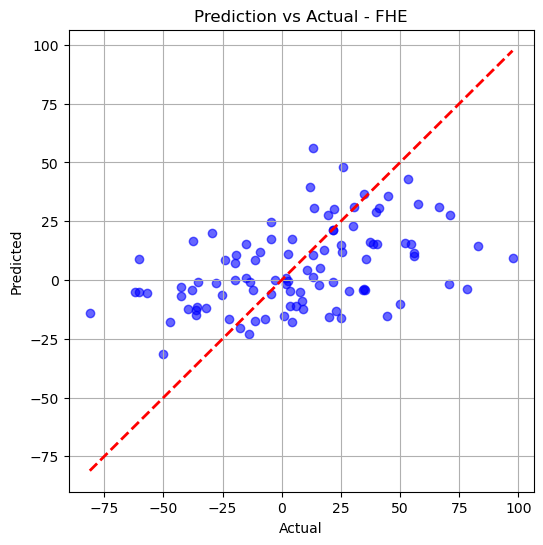

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(md_y_test, md_y_pred_fhe, color='blue', alpha=0.6)
plt.plot([md_y_test.min(), md_y_test.max()],
         [md_y_test.min(), md_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

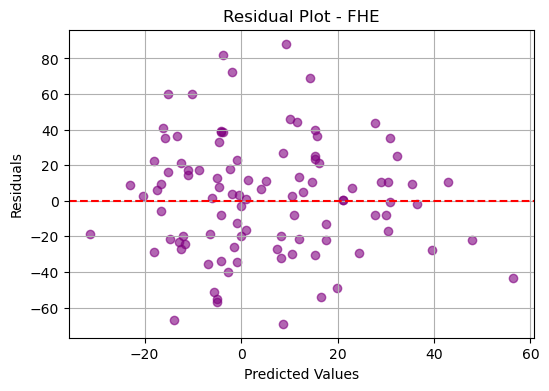

In [27]:
residuals = md_y_test - md_y_pred_fhe

plt.figure(figsize=(6, 4))
plt.scatter(md_y_pred_fhe, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

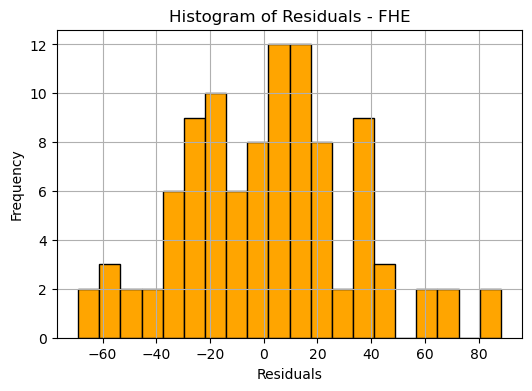

In [28]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of MD Model

In [29]:
print("In clear  :", md_y_pred_clear)
print("In FHE    :", md_y_pred_fhe)
print(f"Similarity: {int((md_y_pred_fhe == md_y_pred_clear).mean()*100)}%")

md_total_end_time = time.time()
md_total_elapsed_time = md_total_end_time - md_total_start_time
print(f"Total time for MD to Run: {md_total_elapsed_time:.5f} seconds")

In clear  : [ 30.45466105  11.0744222   36.45330641 -11.0744222   -5.5372111
   8.30581665  17.53450182  -3.69147407  -4.15290833 -17.53450182
 -11.53585646  15.22733053  -1.84573703  32.30039809 -17.99593608
   8.76725091  15.22733053  -0.92286852 -23.07171292  15.22733053
  16.15019904 -16.6116333   -3.69147407   8.76725091  -4.61434258
   4.15290833  -0.46143426  30.45466105  29.9932268  -13.38159349
  47.98916287  11.99729072 -15.68876479  16.6116333   -1.84573703
 -12.45872498  11.99729072  -0.92286852  35.5304379  -14.76589627
   0.         -15.22733053  -6.46007962  23.07171292 -15.22733053
  -4.15290833 -17.99593608  12.92015924  -5.99864536   1.38430278
  10.61298794 -11.99729072  10.15155368   0.92286852  24.4560157
  -4.15290833  14.76589627  30.91609531  42.91338603   5.07577684
  -0.92286852  -5.07577684  -2.30717129  15.22733053 -11.0744222
  -4.61434258   8.30581665  14.30446201 -12.45872498  39.68334622
 -16.15019904 -31.37752957  15.68876479 -12.92015924   9.22868517
 

# Large Random Dataset - 10,000 samples

Make Samples and Perform Train and Test Split

In [30]:
ld_x, ld_y = make_regression(n_samples=10000, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", ld_x.min())
print("X Maximum: ", ld_x.max())

ld_x_train, ld_x_test, ld_y_train, ld_y_test = train_test_split(ld_x, ld_y, test_size=0.1, random_state=42)

X Minimum:  -3.9224002516183423
X Maximum:  3.9262377064363267


Evaluate number of training and testing samples from train/test split

In [31]:
num_ld_x_training = len(ld_x_train)
num_ld_x_test = len(ld_x_test)
num_ld_y_training = len(ld_y_train)
num_ld_y_test = len(ld_y_test)

print("Number of x training: ", num_ld_x_training)
print("Number of x test: ", num_ld_x_test)
print("Number of y training: ", num_ld_y_training)
print("Number of y test: ", num_ld_y_test)

Number of x training:  9000
Number of x test:  1000
Number of y training:  9000
Number of y test:  1000


In [32]:
print("ld_x_train shape: ", ld_x_train.shape)
print("ld_x_test shape: ", ld_x_test.shape)
print("ld_y_train shape: ", ld_y_train.shape)
print("ld_y_test shape: ", ld_y_train.shape) 

ld_x_train shape:  (9000, 1)
ld_x_test shape:  (1000, 1)
ld_y_train shape:  (9000,)
ld_y_test shape:  (9000,)


Initialise Model and Perform Fitting and Prediction

In [33]:
ld_total_start_time = time.time()

ld_model = LinearRegression(n_bits=8)
ld_ml_start_time = time.time()

ld_model.fit(ld_x_train, ld_y_train)
ld_y_pred_clear = ld_model.predict(ld_x_test)
ld_model.compile(ld_x_train)

ld_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmpo3ebm2zz/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [34]:
ld_clear_mse = mean_squared_error(ld_y_test, ld_y_pred_clear)
ld_clear_mae = mean_absolute_error(ld_y_test, ld_y_pred_clear)
ld_clear_mape = mean_absolute_percentage_error(ld_y_test, ld_y_pred_clear)
ld_clear_r2 = r2_score(ld_y_test, ld_y_pred_clear)
ld_clear_explained_var = explained_variance_score(ld_y_test, ld_y_pred_clear)
ld_ml_elapsed_time = ld_ml_end_time - ld_ml_start_time

print("Mean Squared Error (MSE):", ld_clear_mse)
print("Mean Absolute Error (MAE):", ld_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", ld_clear_mape)
print("R-squared Score (R²):", ld_clear_r2)
print("Explained Variance Score:", ld_clear_explained_var)
print(f"Time it took for ML to make predictions: {ld_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 928.3336122245428
Mean Absolute Error (MAE): 24.219850559987744
Mean Absolute Percentage Error (MAPE): 3.4332869851416525
R-squared Score (R²): 0.5256194066915459
Explained Variance Score: 0.5279866566329119
Time it took for ML to make predictions: 1.39981 seconds


Prediction v Actual Plot - Cleartext

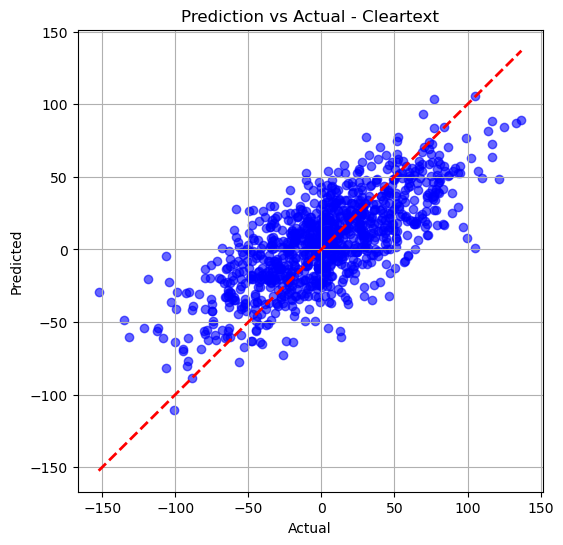

In [35]:
plt.figure(figsize=(6, 6))
plt.scatter(ld_y_test, ld_y_pred_clear, color='blue', alpha=0.6)
plt.plot([ld_y_test.min(), ld_y_test.max()],
         [ld_y_test.min(), ld_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Cleartext

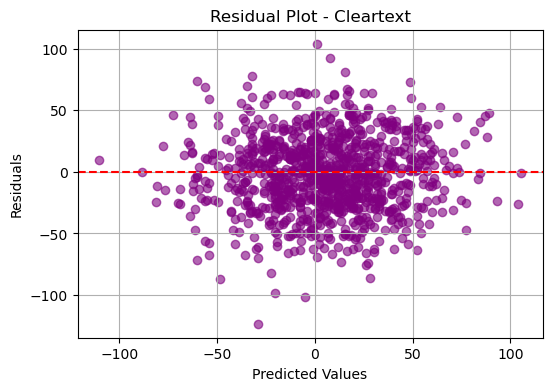

In [36]:
residuals = ld_y_test - ld_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(ld_y_pred_clear, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Ciphertext

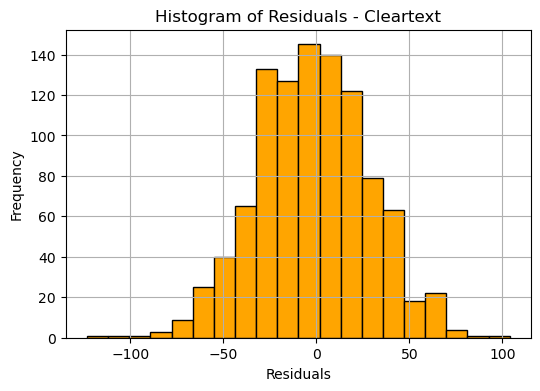

In [37]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

FHE Execution and Evaluation

In [38]:
ld_fhe_prediction_start_time = time.time()

ld_y_pred_fhe = ld_model.predict(ld_x_test, fhe="execute")

ld_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [39]:
ld_fhe_mse = mean_squared_error(ld_y_test, ld_y_pred_fhe)
ld_fhe_mae = mean_absolute_error(ld_y_test, ld_y_pred_fhe)
ld_fhe_mape = mean_absolute_percentage_error(ld_y_test, ld_y_pred_fhe)
ld_fhe_r2 = r2_score(ld_y_test, ld_y_pred_fhe)
ld_fhe_explained_var = explained_variance_score(ld_y_test, ld_y_pred_fhe)
ld_fhe_elapsed_time = ld_fhe_prediction_end_time - ld_fhe_prediction_start_time

print("Mean Squared Error (MSE):", ld_clear_mse)
print("Mean Absolute Error (MAE):", ld_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", ld_clear_mape)
print("R-squared Score (R²):", ld_clear_r2)
print("Explained Variance Score:", ld_clear_explained_var)
print(f"Time it took for FHE to make predictions: {ld_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 928.3336122245428
Mean Absolute Error (MAE): 24.219850559987744
Mean Absolute Percentage Error (MAPE): 3.4332869851416525
R-squared Score (R²): 0.5256194066915459
Explained Variance Score: 0.5279866566329119
Time it took for FHE to make predictions: 15.24378 seconds


Prediction v Actual Plot - FHE

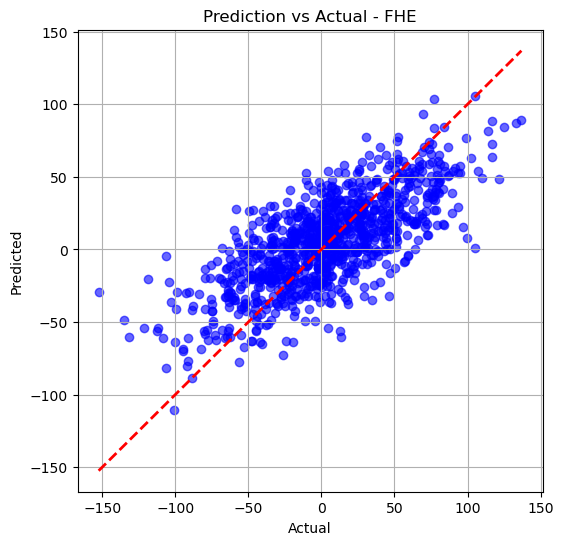

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(ld_y_test, ld_y_pred_fhe, color='blue', alpha=0.6)
plt.plot([ld_y_test.min(), ld_y_test.max()],
         [ld_y_test.min(), ld_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

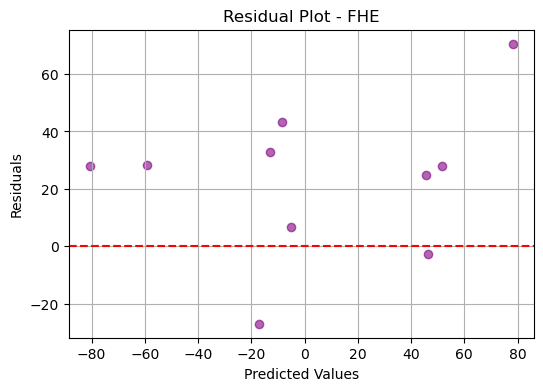

In [41]:
residuals = sd_y_test - sd_y_pred_fhe

plt.figure(figsize=(6, 4))
plt.scatter(sd_y_pred_fhe, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

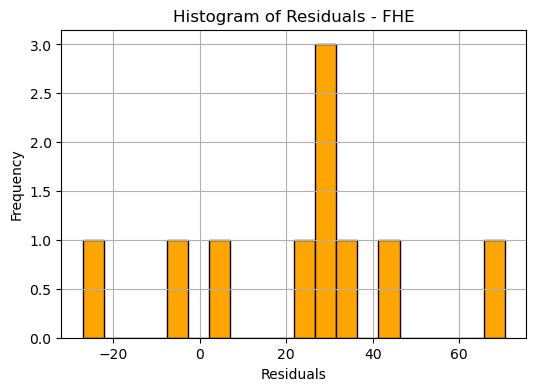

In [42]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of LD Model

In [43]:
print("In clear  :", ld_y_pred_clear)
print("In FHE    :", ld_y_pred_fhe)
print(f"Similarity: {int((ld_y_pred_fhe == ld_y_pred_clear).mean()*100)}%")

ld_total_end_time = time.time()
ld_total_elapsed_time = ld_total_end_time - ld_total_start_time
print(f"Total time for LD to Run: {ld_total_elapsed_time:.5f} seconds")

In clear  : [  -1.93881095  -13.57167665    0.            3.8776219   -54.2867066
  -22.29632593    6.78583833   42.6538409    55.25611208    4.84702738
   49.43967923   30.05156973    7.7552438     0.96940548  -60.10313945
   57.19492303    6.78583833  -18.41870403    0.96940548    8.72464928
   62.04195041   -6.78583833   -2.90821643  -15.5104876    24.23513688
  -20.35751498   -7.7552438    13.57167665   31.0209752   -19.3881095
   -6.78583833   28.11275878   21.32692045  -12.60227118   40.71502995
    6.78583833  -21.32692045    3.8776219    39.74562448   36.83740805
   26.17394783   42.6538409    19.3881095    38.776219     13.57167665
  -27.1433533    20.35751498  -63.98076136   19.3881095    46.5314628
  -22.29632593  -28.11275878  -20.35751498   -9.69405475   84.33827633
  -21.32692045  -18.41870403  -31.0209752   -49.43967923  -54.2867066
  -25.20454235   -8.72464928   47.50086828  -22.29632593   18.41870403
   38.776219      5.81643285   -0.96940548   70.76659968   48.4702737

# High Random Dataset - 100,000 samples

Makes Samples and Perform Train and Test Split

In [44]:
hd_x, hd_y = make_regression(n_samples=100000, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", hd_x.min())
print("X Maximum: ", hd_x.max())

hd_x_train, hd_x_test, hd_y_train, hd_y_test = train_test_split(hd_x, hd_y, test_size=0.1, random_state=42)

X Minimum:  -4.4656038635288775
X Maximum:  4.479084251025757


Evaluate number of training and testing samples from train/test split

In [45]:
num_hd_x_training = len(hd_x_train)
num_hd_x_test = len(hd_x_test)
num_hd_y_training = len(hd_y_train)
num_hd_y_test = len(hd_y_test)

print("Number of x training: ", num_hd_x_training)
print("Number of x test: ", num_hd_x_test)
print("Number of y training: ", num_hd_y_training)
print("Number of y test: ", num_hd_y_test)

Number of x training:  90000
Number of x test:  10000
Number of y training:  90000
Number of y test:  10000


In [46]:
print("hd_x_train shape: ", hd_x_train.shape)
print("hd_x_test shape: ", hd_x_test.shape)
print("hd_y_train shape: ", hd_y_train.shape)
print("hd_y_test shape: ", hd_y_train.shape)

hd_x_train shape:  (90000, 1)
hd_x_test shape:  (10000, 1)
hd_y_train shape:  (90000,)
hd_y_test shape:  (90000,)


Initialise Model and Perform Fitting and Prediction

In [47]:
hd_total_start_time = time.time()

hd_model = LinearRegression(n_bits=8)
hd_ml_start_time = time.time()

hd_model.fit(hd_x_train, hd_y_train)
hd_y_pred_clear = hd_model.predict(hd_x_test)
hd_model.compile(hd_x_train)

hd_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmpt_yl_yqf/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [48]:
hd_clear_mse = mean_squared_error(hd_y_test, hd_y_pred_clear)
hd_clear_mae = mean_absolute_error(hd_y_test, hd_y_pred_clear)
hd_clear_mape = mean_absolute_percentage_error(hd_y_test, hd_y_pred_clear)
hd_clear_r2 = r2_score(hd_y_test, hd_y_pred_clear)
hd_clear_explained_var = explained_variance_score(hd_y_test, hd_y_pred_clear)
hd_ml_elapsed_time = hd_ml_end_time - hd_ml_start_time

print("Mean Squared Error (MSE):", hd_clear_mse)
print("Mean Absolute Error (MAE):", hd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", hd_clear_mape)
print("R-squared Score (R²):", hd_clear_r2)
print("Explained Variance Score:", hd_clear_explained_var)
print(f"Time it took for ML to make predictions: {hd_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 919.2517067815043
Mean Absolute Error (MAE): 24.313651811724153
Mean Absolute Percentage Error (MAPE): 2.480937473174267
R-squared Score (R²): 0.46983427827389956
Explained Variance Score: 0.4699047280281904
Time it took for ML to make predictions: 12.29416 seconds


Prediction v Actual Plot - Cleartext

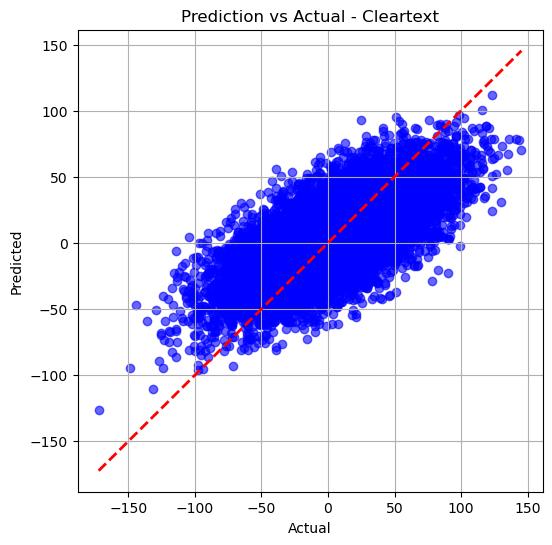

In [49]:
plt.figure(figsize=(6, 6))
plt.scatter(hd_y_test, hd_y_pred_clear, color='blue', alpha=0.6)
plt.plot([hd_y_test.min(), hd_y_test.max()],
         [hd_y_test.min(), hd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Cleartext

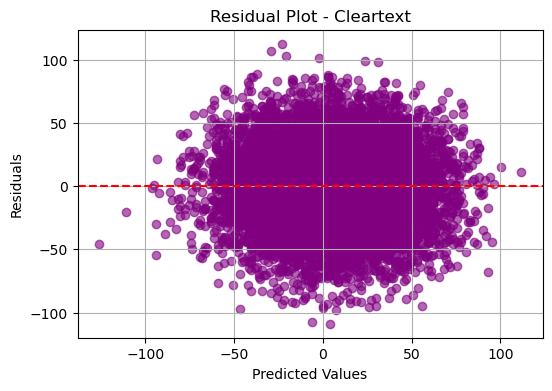

In [50]:
residuals = hd_y_test - hd_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(hd_y_pred_clear, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Cleartext

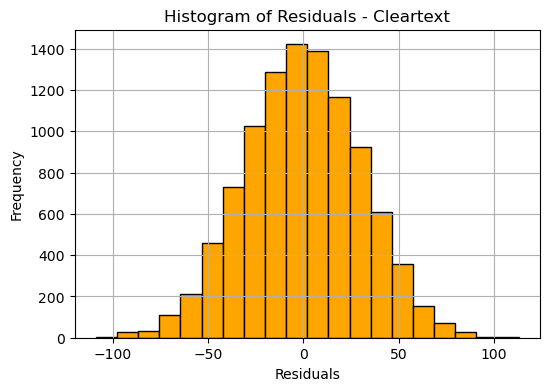

In [51]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

FHE Execution and Evaluation

In [52]:
hd_fhe_prediction_start_time = time.time()

hd_y_pred_fhe = hd_model.predict(hd_x_test, fhe="execute")

hd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [53]:
hd_fhe_mse = mean_squared_error(hd_y_test, hd_y_pred_fhe)
hd_fhe_mae = mean_absolute_error(hd_y_test, hd_y_pred_fhe)
hd_fhe_mape = mean_absolute_percentage_error(hd_y_test, hd_y_pred_fhe)
hd_fhe_r2 = r2_score(hd_y_test, hd_y_pred_fhe)
hd_fhe_explained_var = explained_variance_score(hd_y_test, hd_y_pred_fhe)
hd_fhe_elapsed_time = hd_fhe_prediction_end_time - hd_fhe_prediction_start_time

print("Mean Squared Error (MSE):", hd_clear_mse)
print("Mean Absolute Error (MAE):", hd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", hd_clear_mape)
print("R-squared Score (R²):", hd_clear_r2)
print("Explained Variance Score:", hd_clear_explained_var)
print(f"Time it took for FHE to make predictions: {hd_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 919.2517067815043
Mean Absolute Error (MAE): 24.313651811724153
Mean Absolute Percentage Error (MAPE): 2.480937473174267
R-squared Score (R²): 0.46983427827389956
Explained Variance Score: 0.4699047280281904
Time it took for FHE to make predictions: 151.08725 seconds


Prediction v Actual Plot - FHE

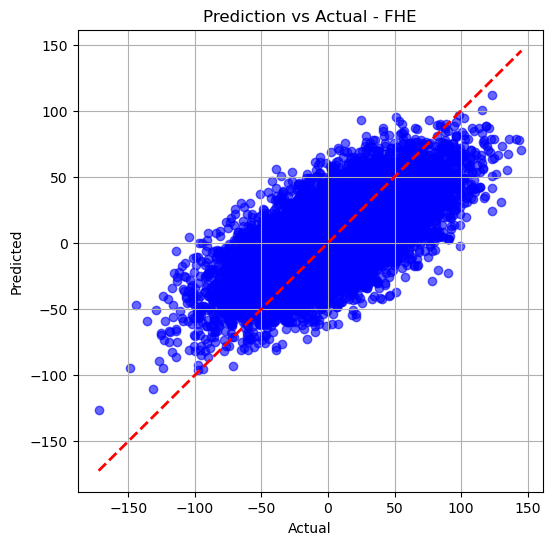

In [54]:
plt.figure(figsize=(6, 6))
plt.scatter(hd_y_test, hd_y_pred_fhe, color='blue', alpha=0.6)
plt.plot([hd_y_test.min(), hd_y_test.max()],
         [hd_y_test.min(), hd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

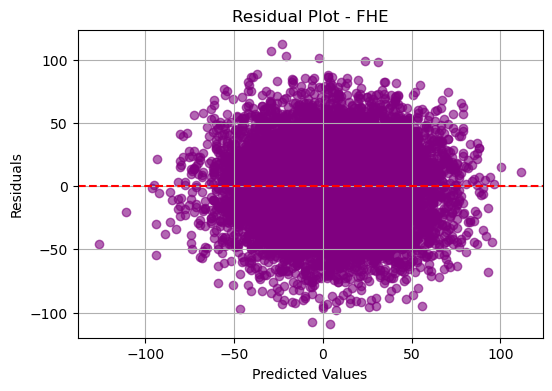

In [55]:
residuals = hd_y_test - hd_y_pred_fhe

plt.figure(figsize=(6, 4))
plt.scatter(hd_y_pred_fhe, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

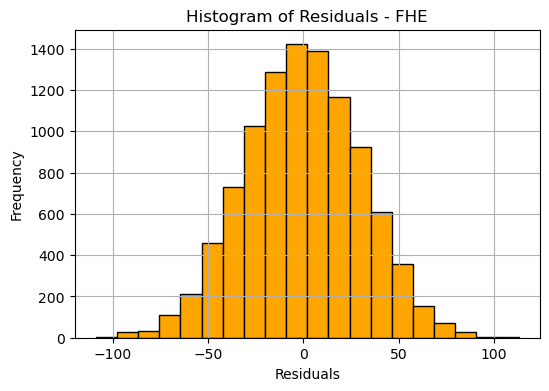

In [56]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of HD Model

In [57]:
print("In clear  :", hd_y_pred_clear)
print("In FHE    :", hd_y_pred_fhe)
print(f"Similarity: {int((hd_y_pred_fhe == hd_y_pred_clear).mean()*100)}%")

hd_total_end_time = time.time()
hd_total_elapsed_time = hd_total_end_time - hd_total_start_time
print(f"Total time for HD to Run: {hd_total_elapsed_time:.5f} seconds")

In clear  : [-34.18270352  29.00350601   4.143358   ... -15.53759251  32.11102452
   3.1075185 ]
In FHE    : [-34.18270352  29.00350601   4.143358   ... -15.53759251  32.11102452
   3.1075185 ]
Similarity: 100%
Total time for HD to Run: 163.97926 seconds


# Mega Random Dataset - 1,000,000 samples

Makes Samples and Perform Train and Test Split

In [58]:
bd_x, bd_y = make_regression(n_samples=1000000, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", bd_x.min())
print("X Maximum: ", bd_x.max())

bd_x_train, bd_x_test, bd_y_train, bd_y_test = train_test_split(bd_x, bd_y, test_size=0.1, random_state=42)

X Minimum:  -4.829436008511157
X Maximum:  4.678949100376725


Evaluate number of training and testing samples from train/test split

In [59]:
num_bd_x_training = len(bd_x_train)
num_bd_x_test = len(bd_x_test)
num_bd_y_training = len(bd_y_train)
num_bd_y_test = len(bd_y_test)

print("Number of x training: ", num_bd_x_training)
print("Number of x test: ", num_bd_x_test)
print("Number of y training: ", num_bd_y_training)
print("Number of y test: ", num_bd_y_test)

Number of x training:  900000
Number of x test:  100000
Number of y training:  900000
Number of y test:  100000


In [60]:
print("bd_x_train shape: ", bd_x_train.shape)
print("bd_x_test shape: ", bd_x_test.shape)
print("bd_y_train shape: ", bd_y_train.shape)
print("bd_y_test shape: ", bd_y_train.shape)

bd_x_train shape:  (900000, 1)
bd_x_test shape:  (100000, 1)
bd_y_train shape:  (900000,)
bd_y_test shape:  (900000,)


Initialise Model and Perform Fitting and Prediction

In [61]:
bd_total_start_time = time.time()

bd_model = LinearRegression(n_bits=8)
bd_ml_start_time = time.time()

bd_model.fit(bd_x_train, bd_y_train)
bd_y_pred_clear = bd_model.predict(bd_x_test)
bd_model.compile(bd_x_train)

bd_ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmpbu45b0xe/sharedlib.dylib'


Evaluate accuracy performed on the cleartext during prediction

In [62]:
bd_clear_mse = mean_squared_error(bd_y_test, bd_y_pred_clear)
bd_clear_mae = mean_absolute_error(bd_y_test, bd_y_pred_clear)
bd_clear_mape = mean_absolute_percentage_error(bd_y_test, bd_y_pred_clear)
bd_clear_r2 = r2_score(bd_y_test, bd_y_pred_clear)
bd_clear_explained_var = explained_variance_score(bd_y_test, bd_y_pred_clear)
bd_ml_elapsed_time = bd_ml_end_time - bd_ml_start_time

print("Mean Squared Error (MSE):", bd_clear_mse)
print("Mean Absolute Error (MAE):", bd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", bd_clear_mape)
print("R-squared Score (R²):", bd_clear_r2)
print("Explained Variance Score:", bd_clear_explained_var)
print(f"Time it took for ML to make predictions: {bd_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 892.0859242532179
Mean Absolute Error (MAE): 23.83341942098629
Mean Absolute Percentage Error (MAPE): 3.2392072803806284
R-squared Score (R²): 0.3337444751904056
Explained Variance Score: 0.3337744595304527
Time it took for ML to make predictions: 125.17537 seconds


Prediction v Actual Plot - Cleartext

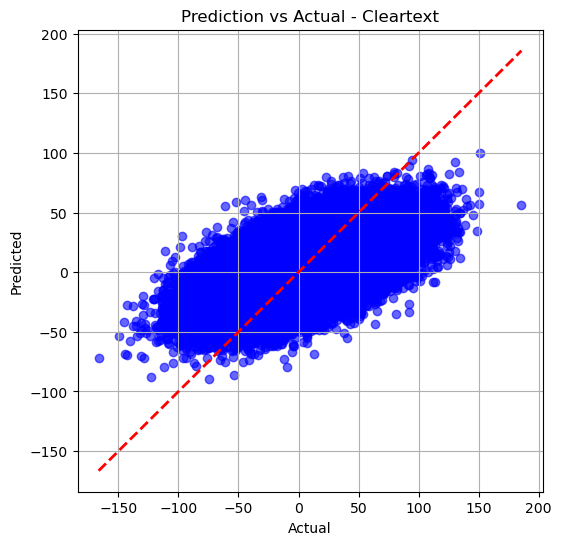

In [63]:
plt.figure(figsize=(6, 6))
plt.scatter(bd_y_test, bd_y_pred_clear, color='blue', alpha=0.6)
plt.plot([bd_y_test.min(), bd_y_test.max()],
         [bd_y_test.min(), bd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Ciphertext

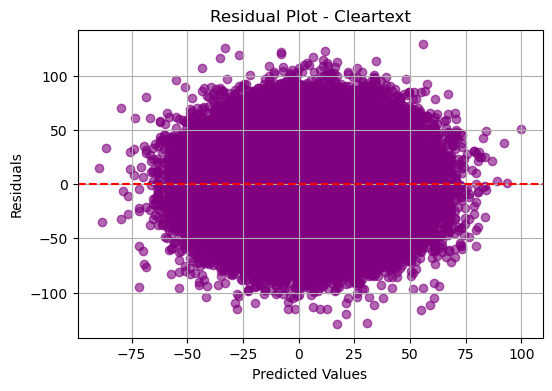

In [64]:
residuals = bd_y_test - bd_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(bd_y_pred_clear, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Cleartext

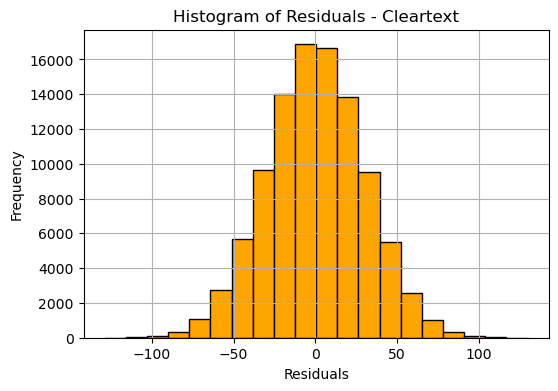

In [65]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

FHE Execution and Evaluation

In [66]:
bd_fhe_prediction_start_time = time.time()

bd_y_pred_fhe = bd_model.predict(bd_x_test, fhe="execute")

bd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [67]:
bd_fhe_mse = mean_squared_error(bd_y_test, bd_y_pred_fhe)
bd_fhe_mae = mean_absolute_error(bd_y_test, bd_y_pred_fhe)
bd_fhe_mape = mean_absolute_percentage_error(bd_y_test, bd_y_pred_fhe)
bd_fhe_r2 = r2_score(bd_y_test, bd_y_pred_fhe)
bd_fhe_explained_var = explained_variance_score(bd_y_test, bd_y_pred_fhe)
bd_fhe_elapsed_time = bd_fhe_prediction_end_time - bd_fhe_prediction_start_time

print("Mean Squared Error (MSE):", bd_clear_mse)
print("Mean Absolute Error (MAE):", bd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", bd_clear_mape)
print("R-squared Score (R²):", bd_clear_r2)
print("Explained Variance Score:", bd_clear_explained_var)
print(f"Time it took for FHE to make predictions: {bd_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 892.0859242532179
Mean Absolute Error (MAE): 23.83341942098629
Mean Absolute Percentage Error (MAPE): 3.2392072803806284
R-squared Score (R²): 0.3337444751904056
Explained Variance Score: 0.3337744595304527
Time it took for FHE to make predictions: 1502.56314 seconds


Prediction v Actual Plot - FHE

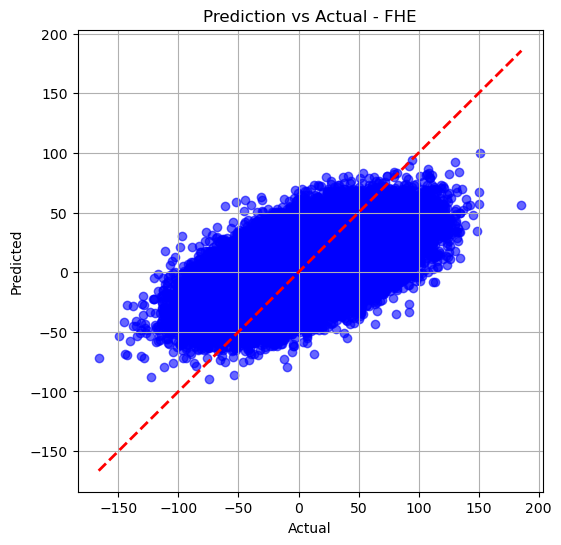

In [68]:
plt.figure(figsize=(6, 6))
plt.scatter(bd_y_test, bd_y_pred_fhe, color='blue', alpha=0.6)
plt.plot([bd_y_test.min(), bd_y_test.max()],
         [bd_y_test.min(), bd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

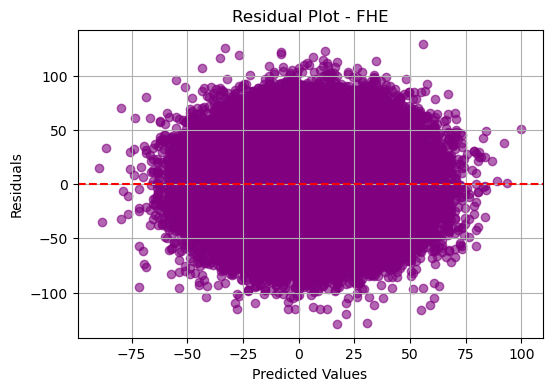

In [69]:
residuals = bd_y_test - bd_y_pred_fhe

plt.figure(figsize=(6, 4))
plt.scatter(bd_y_pred_fhe, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

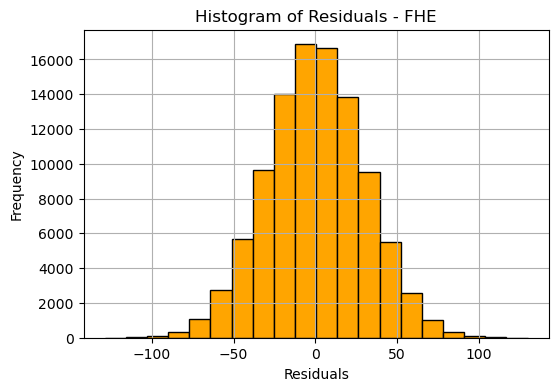

In [70]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of BD Model

In [71]:
print("In clear  :", bd_y_pred_clear)
print("In FHE    :", bd_y_pred_fhe)
print(f"Similarity: {int((bd_y_pred_fhe == bd_y_pred_clear).mean()*100)}%")

bd_total_end_time = time.time()
bd_total_elapsed_time = bd_total_end_time - bd_total_start_time
print(f"Total time for BD to Run: {bd_total_elapsed_time:.5f} seconds")

In clear  : [ 33.85049605 -29.12717102  30.7016127  ...  -8.65942922 -22.82940431
  28.33995018]
In FHE    : [ 33.85049605 -29.12717102  30.7016127  ...  -8.65942922 -22.82940431
  28.33995018]
Similarity: 100%
Total time for BD to Run: 1628.62076 seconds


# Combined Evaluation of Concrete Models

In [72]:
results = {
     '100 Dataset':["100", 
     f"{(sd_y_pred_fhe == sd_y_pred_clear).mean() * 100:.0f}%", 
     sd_ml_elapsed_time,
     sd_clear_mse,
     sd_clear_mae,
     sd_clear_mape,
     sd_clear_r2,
     sd_clear_explained_var,
     sd_fhe_mse,
     sd_fhe_mae,
     sd_fhe_mape,
     sd_fhe_r2,
     sd_fhe_explained_var,
     sd_fhe_elapsed_time,
     sd_total_elapsed_time],
     '1000 Dataset':["100", 
     f"{(md_y_pred_fhe == md_y_pred_clear).mean() * 100:.0f}%", 
     md_ml_elapsed_time,
     md_clear_mse,
     md_clear_mae,
     md_clear_mape,
     md_clear_r2,
     md_clear_explained_var,
     md_fhe_mse,
     md_fhe_mae,
     md_fhe_mape,
     md_fhe_r2,
     md_fhe_explained_var,
     md_fhe_elapsed_time,
     md_total_elapsed_time],
     '10000 Dataset':["100", 
     f"{(ld_y_pred_fhe == ld_y_pred_clear).mean() * 100:.0f}%", 
     ld_ml_elapsed_time,
     ld_clear_mse,
     ld_clear_mae,
     ld_clear_mape,
     ld_clear_r2,
     ld_clear_explained_var,
     ld_fhe_mse,
     ld_fhe_mae,
     ld_fhe_mape,
     ld_fhe_r2,
     ld_fhe_explained_var,
     ld_fhe_elapsed_time,
     ld_total_elapsed_time],
     '100000 Dataset':["100", 
     f"{(hd_y_pred_fhe == hd_y_pred_clear).mean() * 100:.0f}%", 
     hd_ml_elapsed_time,
     hd_clear_mse,
     hd_clear_mae,
     hd_clear_mape,
     hd_clear_r2,
     hd_clear_explained_var,
     hd_fhe_mse,
     hd_fhe_mae,
     hd_fhe_mape,
     hd_fhe_r2,
     hd_fhe_explained_var,
     hd_fhe_elapsed_time,
     hd_total_elapsed_time],
     '1000000 Dataset':["100", 
     f"{(bd_y_pred_fhe == bd_y_pred_clear).mean() * 100:.0f}%", 
     bd_ml_elapsed_time,
     bd_clear_mse,
     bd_clear_mae,
     bd_clear_mape,
     bd_clear_r2,
     bd_clear_explained_var,
     bd_fhe_mse,
     bd_fhe_mae,
     bd_fhe_mape,
     bd_fhe_r2,
     bd_fhe_explained_var,
     bd_fhe_elapsed_time,
     bd_total_elapsed_time]
}

headers = ['Samples', 'Similarity', 'ML Time', 'CT MSE','CT MAE', 'CT MAPE', 'CT R2', 'CT EVS', 
           'FHE MSE', 'FHE MAE', 'FHE MAPE', 'FHE R2', 'FHE EVS', 'FHE TIME', 'Total Time']

overall_results = pd.DataFrame(results, index=headers).T.round(2)
overall_results


,Samples,Similarity,ML Time,CT MSE,CT MAE,CT MAPE,CT R2,CT EVS,FHE MSE,FHE MAE,FHE MAPE,FHE R2,FHE EVS,FHE TIME,Total Time
100 Dataset,100,100%,0.166444,1170.14699,29.235289,1.026348,0.668436,0.822146,1170.14699,29.235289,1.026348,0.668436,0.822146,0.50339,1.256935
1000 Dataset,100,100%,0.236908,1031.817173,25.582955,1.338145,0.18847,0.19142,1031.817173,25.582955,1.338145,0.18847,0.19142,1.748009,2.475412
10000 Dataset,100,100%,1.399813,928.333612,24.219851,3.433287,0.525619,0.527987,928.333612,24.219851,3.433287,0.525619,0.527987,15.243785,17.104224
100000 Dataset,100,100%,12.294162,919.251707,24.313652,2.480937,0.469834,0.469905,919.251707,24.313652,2.480937,0.469834,0.469905,151.087252,163.979263
1000000 Dataset,100,100%,125.175366,892.085924,23.833419,3.239207,0.333744,0.333774,892.085924,23.833419,3.239207,0.333744,0.333774,1502.563135,1628.620761
